In [1]:
import pickle
import pandas as pd
import copy
import numpy as np
import ast
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

from _helper_functions import cb
from _helper_functions import dprint


# A function to get all single flips of an element

In [2]:
def get_all_single_orientation_flips(tfbsSeq):
    tfbsSeq=tfbsSeq.split('-')
    yield 'no flip','-'.join(tfbsSeq)
    
    # Iterate over all elements
    for idx,tfbs in enumerate(tfbsSeq):
        
        # skip if spacer
        if tfbs[0]=='L': continue
        
        # Flip orientation
        tfbs=list(tfbs)
        if tfbs[-1]=='F':
            tfbs[-1]='R'
        elif tfbs[-1]=='R':
            tfbs[-1]='F'
        tfbs=''.join(tfbs)
        
        outTfbsSeq=copy.deepcopy(tfbsSeq)
        outTfbsSeq[idx]=tfbs
        yield tfbsSeq[idx][:2],'-'.join(outTfbsSeq)
        

for i in get_all_single_orientation_flips('L5-G3R-L4-G2F-L3-E2R-L2-E1R-L1-G1F-L6'):
    print(i)

('no flip', 'L5-G3R-L4-G2F-L3-E2R-L2-E1R-L1-G1F-L6')
('G3', 'L5-G3F-L4-G2F-L3-E2R-L2-E1R-L1-G1F-L6')
('G2', 'L5-G3R-L4-G2R-L3-E2R-L2-E1R-L1-G1F-L6')
('E2', 'L5-G3R-L4-G2F-L3-E2F-L2-E1R-L1-G1F-L6')
('E1', 'L5-G3R-L4-G2F-L3-E2R-L2-E1F-L1-G1F-L6')
('G1', 'L5-G3R-L4-G2F-L3-E2R-L2-E1R-L1-G1R-L6')


# load mpra data

In [ ]:
# Load all data
fn='supp/endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle'
allDF=pd.read_pickle(fn).set_index('enhancer-sites',drop=True)
allDF.head()

,enhancer-id,wt-enhancer-seq,wt-control-name,wt-control-label,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
enhancer-sites,,,,,,,,,
S1-G1R-S2-E1F-S3-E2F-S4-G2R-S5-G3F-S6,OLS:0,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,OLS WT,Neural,1.197798,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.848065,"(1, 0)",0
S1-G1F-S2-E1F-S3-E2F-S4-G2R-S5-G3F-S6,OLS:1,CATCTGAAGCTCGAGATAACTAACGGAAGTTTTCGAAAAGGAAATT...,NaN,NaN,0.856235,CATCTGAAGCTCGAAATAACTAACGCAAGTTTTCGAAAAGCAAATT...,-1.100699,"(0, -1)",0
S1-G1R-S2-E1F-S3-E2F-S4-G2F-S5-G3F-S6,OLS:2,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,NaN,NaN,0.777169,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.706492,"(0, 0)",0
S1-G1R-S2-E1F-S3-E2F-S4-G2R-S5-G3R-S6,OLS:3,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,NaN,NaN,NaN,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,-1.486866,"(0, -1)",0
S1-G1R-S2-E1R-S3-E2F-S4-G2R-S5-G3F-S6,OLS:4,CATCTGAAGCTCGTTATCTCTAACTTCCGTTTTCGAAAAGGAAATT...,NaN,NaN,0.518839,CATCTGAAGCTCGTTATTTCTAACTTGCGTTTTCGAAAAGCAAATT...,-1.322202,"(0, -1)",0


In [17]:
# load functional enhancers as 
funcDF=allDF.loc[allDF['enhancer-dependent-gata-ets']==1,:]
funcDF.head()

,enhancer-id,wt-enhancer-seq,wt-control-name,wt-control-label,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
enhancer-sites,,,,,,,,,
S1-G1F-S2-E1F-S3-E2F-S4-G2R-S5-G3R-S6,OLS:7,CATCTGAAGCTCGAGATAACTAACGGAAGTTTTCGAAAAGGAAATT...,NaN,NaN,1.249433,CATCTGAAGCTCGAAATAACTAACGCAAGTTTTCGAAAAGCAAATT...,-0.258002,"(1, -1)",1
S1-G1F-S2-E1R-S3-E2F-S4-G2R-S5-G3F-S6,OLS:8,CATCTGAAGCTCGAGATAACTAACTTCCGTTTTCGAAAAGGAAATT...,NaN,NaN,1.375287,CATCTGAAGCTCGAAATAACTAACTTGCGTTTTCGAAAAGCAAATT...,NaN,"(1, -1)",1
S1-G1R-S2-E1R-S3-E2F-S4-G2F-S5-G3R-S6,OLS:22,CATCTGAAGCTCGTTATCTCTAACTTCCGTTTTCGAAAAGGAAATT...,NaN,NaN,1.614942,CATCTGAAGCTCGTTATTTCTAACTTGCGTTTTCGAAAAGCAAATT...,-0.449367,"(1, -1)",1
S1-G1F-S2-E1R-S3-E2F-S4-G2F-S5-G3R-S6,OLS:26,CATCTGAAGCTCGAGATAACTAACTTCCGTTTTCGAAAAGGAAATT...,NaN,NaN,1.343622,CATCTGAAGCTCGAAATAACTAACTTGCGTTTTCGAAAAGCAAATT...,NaN,"(1, -1)",1
S1-G1F-S2-E1R-S3-E2R-S4-G2R-S5-G3R-S6,OLS:29,CATCTGAAGCTCGAGATAACTAACTTCCGTTTTCGAAATTTCCTTT...,NaN,NaN,1.336315,CATCTGAAGCTCGAAATAACTAACTTGCGTTTTCGAAATTTGCTTT...,NaN,"(1, -1)",1


In [18]:
fn='supp/OlsEnSeq2Id.pydict.pickle'
with open(fn,'rb') as f: OlsEnSeq2Id=pickle.load(f)
dprint(OlsEnSeq2Id)

CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA Otx-a WT


In [19]:
fn='supp/OLSEnSeq2Name.pydict.pickle'
with open(fn,'rb') as f: OLSEnSeq2Name=pickle.load(f)
dprint(OLSEnSeq2Name)

CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6


In [20]:
OLSName2Seq={v:k for k,v in OLSEnSeq2Name.items()}
dprint(OLSName2Seq)

L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6 CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA


# Single flips that convert inert to active

In [35]:
allDF['enhancer-id-save'] = allDF['enhancer-id'].copy()

In [36]:
allDF['enhancer-id'] = allDF['wt-enhancer-seq'].map(OlsEnSeq2Id)

In [43]:
allDF['site_index'] = allDF['wt-enhancer-seq'].map(OLSEnSeq2Name)

In [48]:
allDF.set_index('site_index', inplace=True)

In [50]:
# Get negative enhancers
thresholdToLabelPositives = 1
thresholdToLabelNegatives = 0

activityColumn='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'
ablColumn='abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'

idxSet=set(allDF.index)

inertElementIdList=[]

for enID in allDF.index:
    
    activity=allDF.at[enID,activityColumn]
    
    if activity<=thresholdToLabelNegatives:
        inertElementIdList.append(enID)
    
print('num inert variants:',len(inertElementIdList))


num inert variants: 143799


In [51]:

enIdWithFunctionalFlips=[] # enhancer ids which can be converted from inert to neural with a single flip
beforeFlip=[] # activity before flip
afterFlip=[]  # activity after flip

numFuncVariantsDetected=0

numSingleFlipsPerSeq=[]
x=0

# keep track of how many gata/ets flips convert inert elements to active enhancers
tf2flips={'G':0,'E':0}
tfaff2flips={'G1':0,'G2':0,'G3':0,'E1':0,'E2':0}

c2v={c:[] for c in ['inert-seq','func-seq','inert-sites','func-sites','inert-activity','func-activity']}

for enID in inertElementIdList:
    
    x+=1
    
    beforeFlipActivity=allDF.at[enID,activityColumn]
    enSeq=allDF.at[enID,'wt-enhancer-seq']
    tfbsList=OLSEnSeq2Name[enSeq]
    
    #################################################################
    # Iterate through all single flips
    #################################################################
    
    IdList=[]
    dataActivity=[]
    
    # print('start',tfbsList)
    
    for siteFlipped,variantTfbsList in get_all_single_orientation_flips(tfbsList):

        if siteFlipped=='no flip': continue

        en=OLSName2Seq[variantTfbsList]
            
        if variantTfbsList in allDF.index:

            activity   =allDF.at[variantTfbsList,activityColumn]
            activityAbl=allDF.at[variantTfbsList,ablColumn]
            
            # if abl not detected, assume 0
            if pd.isnull(activityAbl):
                activityAbl=0
            
            # Do not count variant if abl is funcitonal
            if activityAbl>thresholdToLabelPositives: 
                continue
            
            dataActivity.append((siteFlipped,activity,activityAbl))
            IdList.append(variantTfbsList)

        else: raise ValueError('enhancer not detected')
        
    # Check to see if any are confident positive requiring ABL==0
    activityOfFunctionalSingleFlips=[(siteFlipped,aWT) for siteFlipped,aWT,aABL in dataActivity if aWT>=thresholdToLabelPositives and aABL<=thresholdToLabelNegatives]
    numFuncVariantsDetected+=len(activityOfFunctionalSingleFlips)
    
    
    if len(activityOfFunctionalSingleFlips)>0:
        
        enIdWithFunctionalFlips.append(enID)

        for siteFlipped,a in activityOfFunctionalSingleFlips:
            
            
            
            beforeFlip.append(beforeFlipActivity)
            afterFlip .append(a)
            
            tf2flips[siteFlipped[0]]+=1
            tfaff2flips[siteFlipped[:2]]+=1

            # get syntax family annotation of the after flip
            afterflipID=[]
            for site in enID.split('-'):
                if site[:2]==siteFlipped:
                    ori=site[2]
                    if ori=='F': afterflipID.append(site[:2]+"R")
                    if ori=='R': afterflipID.append(site[:2]+"F")
                else:
                    afterflipID.append(site)
                    

            afterflipID='-'.join(afterflipID)

            beforeseq=OLSName2Seq[enID]
            afterseq=OLSName2Seq[afterflipID]
            
            c2v['inert-seq'].append(beforeseq)
            c2v['func-seq'].append(afterseq)
            c2v['inert-sites'].append(enID)
            c2v['func-sites'].append(afterflipID)
            c2v['inert-activity'].append(allDF.at[enID,activityColumn])
            c2v['func-activity'].append(allDF.at[afterflipID,activityColumn])
            
        numSingleFlipsPerSeq.append(len(activityOfFunctionalSingleFlips))

print('done!')

done!


[Text(0, 0, '\nInert\nSequence'),
 Text(1, 0, '\nSingle Flip\nConverts Inert\nTo Functional')]

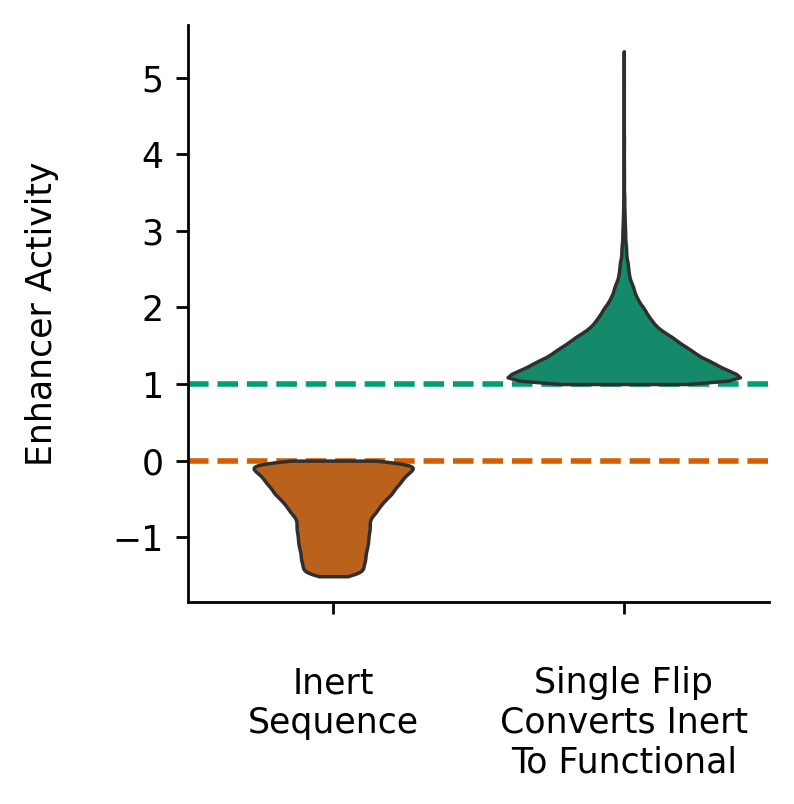

In [10]:
fig,ax=plt.subplots(1,figsize=(3,3),dpi=250)

lc=1

beforelist=[]
afterlist=[]
for before,after in zip(beforeFlip,afterFlip):
    lc+=1

    beforelist.append(before)
    afterlist.append(after)
    
    
sns.violinplot(data=[beforelist,afterlist],palette=[cb['red'],cb['green']],cut=0,inner=None,linewidth=1)
    
plt.axhline(thresholdToLabelPositives,color=cb['green'],ls='--',lw=1.6,zorder=0)
plt.axhline(thresholdToLabelNegatives,color=cb['red'],ls='--', lw=1.6,zorder=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel(activityColumn)
ax.set_ylabel("Enhancer Activity\n")

ax.set_xticks([0,1])
ax.set_xticklabels(['\nInert\nSequence','\nSingle Flip\nConverts Inert\nTo Functional'])



# effect of flip on syntax family

In [53]:
fn='supp/syntax-fam-Bin2Annotation.pydict.pickle'
with open(fn,'rb') as f: bin2anno=pickle.load(f)

In [54]:
fn='supp/OLSName2SyntaxFamily-vary-aff.pydict.pickle'
with open(fn,'rb') as f:
    OLSName2SyntaxFamily=pickle.load(f)
dprint(OLSName2SyntaxFamily)    

L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6 L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6


In [55]:
fn='supp/SyntaxFamily2OLSName-vary-aff.pydict.pickle'
with open(fn,'rb') as f:
    SyntaxFamily2OLSName=pickle.load(f)
dprint(SyntaxFamily2OLSName)        

L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6 {'L1-G3R-L2-E1F-L3-E2F-L4-G2R-L5-G1F-L6', 'L1-G2R-L2-E2F-L3-E1F-L4-G3R-L5-G1F-L6', 'L1-G2R-L2-E1F-L3-E2F-L4-G3R-L5-G1F-L6', 'L1-G1R-L2-E2F-L3-E1F-L4-G2R-L5-G3F-L6', 'L1-G3R-L2-E2F-L3-E1F-L4-G1R-L5-G2F-L6', 'L1-G1R-L2-E1F-L3-E2F-L4-G3R-L5-G2F-L6', 'L1-G2R-L2-E2F-L3-E1F-L4-G1R-L5-G3F-L6', 'L1-G1R-L2-E2F-L3-E1F-L4-G3R-L5-G2F-L6', 'L1-G2R-L2-E1F-L3-E2F-L4-G1R-L5-G3F-L6', 'L1-G3R-L2-E2F-L3-E1F-L4-G2R-L5-G1F-L6', 'L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6', 'L1-G3R-L2-E1F-L3-E2F-L4-G1R-L5-G2F-L6'}


In [56]:
fn='supp/OLSEnSeq2Name.pydict.pickle'
with open(fn,'rb') as f:
    OLSEnSeq2Sites=pickle.load(f)

OLSSites2Seq={sites:seq for seq,sites in OLSEnSeq2Sites.items()}
dprint(OLSSites2Seq)

L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6 CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA


In [57]:
OLSSeq2Sites={v:k for k,v in OLSSites2Seq.items()}
dprint(OLSSeq2Sites)

CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6


In [61]:
sdf

,syntax-family,n-func,n-inert,n-func-inert-tuple,n-func-inert-tuple-permute-0,n-func-inert-tuple-permute-1,n-func-inert-tuple-permute-2,n-func-inert-tuple-permute-3,n-func-inert-tuple-permute-4,n-func-inert-tuple-permute-5,...,n-func-inert-tuple-permute-90,n-func-inert-tuple-permute-91,n-func-inert-tuple-permute-92,n-func-inert-tuple-permute-93,n-func-inert-tuple-permute-94,n-func-inert-tuple-permute-95,n-func-inert-tuple-permute-96,n-func-inert-tuple-permute-97,n-func-inert-tuple-permute-98,n-func-inert-tuple-permute-99
syntax-family,,,,,,,,,,,,,,,,,,,,,
L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6,L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6,1,5,"(1, 5)","(1, 6)","(0, 8)","(0, 9)","(2, 7)","(0, 6)","(2, 7)",...,"(0, 7)","(1, 5)","(3, 8)","(1, 8)","(3, 6)","(2, 6)","(0, 7)","(3, 4)","(1, 8)","(2, 5)"
L1-GF-L2-EF-L3-EF-L4-GR-L5-GF-L6,L1-GF-L2-EF-L3-EF-L4-GR-L5-GF-L6,1,8,"(1, 8)","(0, 9)","(0, 9)","(0, 7)","(2, 8)","(0, 7)","(2, 8)",...,"(1, 6)","(1, 7)","(1, 5)","(0, 7)","(2, 6)","(0, 7)","(1, 8)","(3, 6)","(1, 6)","(0, 7)"
L1-GR-L2-EF-L3-EF-L4-GF-L5-GF-L6,L1-GR-L2-EF-L3-EF-L4-GF-L5-GF-L6,1,5,"(1, 5)","(3, 1)","(4, 4)","(1, 7)","(3, 5)","(2, 3)","(4, 4)",...,"(1, 6)","(1, 7)","(2, 3)","(1, 6)","(1, 3)","(4, 6)","(2, 7)","(1, 4)","(1, 3)","(0, 6)"
L1-GR-L2-EF-L3-EF-L4-GR-L5-GR-L6,L1-GR-L2-EF-L3-EF-L4-GR-L5-GR-L6,2,5,"(2, 5)","(1, 5)","(0, 8)","(2, 8)","(2, 6)","(2, 8)","(1, 7)",...,"(1, 5)","(0, 5)","(1, 6)","(2, 6)","(0, 9)","(2, 6)","(2, 8)","(1, 6)","(2, 7)","(0, 6)"
L1-GR-L2-ER-L3-EF-L4-GR-L5-GF-L6,L1-GR-L2-ER-L3-EF-L4-GR-L5-GF-L6,3,3,"(3, 3)","(0, 6)","(2, 3)","(0, 8)","(1, 7)","(1, 4)","(1, 7)",...,"(4, 4)","(0, 7)","(1, 7)","(0, 5)","(2, 4)","(1, 7)","(0, 8)","(1, 7)","(0, 5)","(1, 9)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L5-EF-L4-ER-L3-GF-L2-GF-L1-GR-L6,L5-EF-L4-ER-L3-GF-L2-GF-L1-GR-L6,1,7,"(1, 7)","(0, 8)","(1, 9)","(0, 8)","(4, 5)","(3, 5)","(0, 7)",...,"(0, 6)","(1, 7)","(0, 8)","(1, 6)","(0, 11)","(3, 6)","(1, 6)","(0, 8)","(2, 5)","(2, 7)"
L5-ER-L4-ER-L3-GF-L2-GF-L1-GF-L6,L5-ER-L4-ER-L3-GF-L2-GF-L1-GF-L6,1,3,"(1, 3)","(1, 5)","(0, 6)","(1, 9)","(1, 7)","(1, 8)","(3, 7)",...,"(1, 7)","(2, 6)","(2, 4)","(1, 7)","(0, 6)","(1, 6)","(2, 7)","(0, 4)","(2, 6)","(1, 6)"
L5-ER-L4-ER-L3-GF-L2-GR-L1-GR-L6,L5-ER-L4-ER-L3-GF-L2-GR-L1-GR-L6,1,4,"(1, 4)","(1, 5)","(2, 5)","(3, 5)","(2, 4)","(2, 5)","(2, 6)",...,"(3, 6)","(0, 5)","(3, 7)","(2, 3)","(1, 4)","(1, 6)","(1, 6)","(2, 6)","(3, 4)","(1, 5)"


In [ ]:
# load syntax family to bin location

# Note the input is the result of a permutation, so each round the figures can look slightly different
# but overall the trend stays the same
fn='supp/syntax-family-analysis-table-with-permuted-data_numiters=100_depGE.pd.df.pickle'
sdf=pd.read_pickle(fn).set_index('syntax-family',drop=False)
sdf.loc[:, "n-func-inert-tuple"] = sdf["n-func-inert-tuple"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
sdf=sdf.loc[:,'n-func-inert-tuple']
sdf.head(1)

syntax-family
L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6    (1, 5)
Name: n-func-inert-tuple, dtype: object

In [63]:
# Get single flips which cause function
enIdWithFunctionalFlips=[]
beforeFlip=[] # activity before flip
afterFlip=[]  # activity after flip

numFuncVariantsDetected=0

numSingleFlipsPerSeq=[]
x=0

tf2flips={'G':0,'E':0}
tfaff2flips={'G1':0,'G2':0,'G3':0,'E1':0,'E2':0}

tfaff2affOfResultingEnhancer={'G1':[],'G2':[],'G3':[],'E1':[],'E2':[]}

synfam2tfaff2flips={sf:{k:v for k,v  in tfaff2flips.items()} for sf in ['Inert', 'Moderate', 'Robust','']}

sf2sf2tfaff2flips={sfi:{sfj:{k:v for k,v  in tfaff2flips.items()} for sfj in ['Inert', 'Moderate', 'Robust','']} for sfi in ['Inert', 'Moderate', 'Robust','']}

tfaff2syndeltas={'G1':[],'G2':[],'G3':[],'E1':[],'E2':[]}
sf2sf2tfaff2syndeltas={sfi:{sfj:{'G1':[],'G2':[],'G3':[],'E1':[],'E2':[]} for sfj in ['Inert', 'Moderate', 'Robust','Not Labeled']} for sfi in ['Inert', 'Moderate', 'Robust','Not Labeled']}

c2v={c:[] for c in ['start-sites','after-sites','site-flipped']}

flip2synbin2numflips={'before':{},'after':{}}

for enID in inertElementIdList:
    
    x+=1
    
    beforeFlipActivity=allDF.at[enID,activityColumn]
    enSeq=allDF.at[enID,'wt-enhancer-seq']
    tfbsList=OLSEnSeq2Name[enSeq]
    
    #################################################################
    # Iterate through all single flips
    #################################################################
    
    IdList=[]
    dataActivity=[]
        
    for siteFlipped,variantTfbsList in get_all_single_orientation_flips(tfbsList):
        
        if siteFlipped=='no flip': continue

        en=OLSName2Seq[variantTfbsList]        
            
        if variantTfbsList in allDF.index:
            activity   =allDF.at[variantTfbsList,activityColumn]
            activityAbl=allDF.at[variantTfbsList,ablColumn]
            
            # if abl not detected, assume 0
            if pd.isnull(activityAbl):
                activityAbl=0
            
            # Do not count variant if abl is funcitonal
            if activityAbl>thresholdToLabelPositives: 
                continue
            
            dataActivity.append((siteFlipped,activity,activityAbl))
            IdList.append(variantTfbsList)

        else: raise ValueError('enhancer not detected')
        
    # Check to see if any are confident positive requiring ABL==0
    activityOfFunctionalSingleFlips=[(siteFlipped,aWT) for siteFlipped,aWT,aABL in dataActivity if aWT>=thresholdToLabelPositives and aABL<=thresholdToLabelNegatives]
    numFuncVariantsDetected+=len(activityOfFunctionalSingleFlips)
    
    if len(activityOfFunctionalSingleFlips)>0:
        
        enIdWithFunctionalFlips.append(enID)
        for siteFlipped,a in activityOfFunctionalSingleFlips:
            
            
            
            beforeFlip.append(beforeFlipActivity)
            afterFlip .append(a)
            
            tf2flips[siteFlipped[0]]+=1
            tfaff2flips[siteFlipped[:2]]+=1
            
            tfaff2affOfResultingEnhancer[siteFlipped[:2]].append(a)
            
            # get syntax family annotation of the before flip
            synfam=OLSName2SyntaxFamily[enID]
            synbin=sdf[synfam]
            
            if synbin not in flip2synbin2numflips['before']:
                flip2synbin2numflips['before'][synbin]=0
            flip2synbin2numflips['before'][synbin]+=1
            
            if synbin in bin2anno: synanno=bin2anno[synbin]
            else:                  synanno='Not Labeled'
            
            synfam2tfaff2flips[synanno][siteFlipped[:2]]+=1

            # get syntax family annotation of the after flip
            afterflipID=[]
            for site in enID.split('-'):
                if site[:2]==siteFlipped:
                    ori=site[2]
                    if ori=='F': afterflipID.append(site[:2]+"R")
                    if ori=='R': afterflipID.append(site[:2]+"F")
                else:
                    afterflipID.append(site)
                    

            afterflipID='-'.join(afterflipID)
            aftersynfam=OLSName2SyntaxFamily[afterflipID]
            aftersynbin=sdf[aftersynfam]

            if aftersynbin not in flip2synbin2numflips['after']:
                flip2synbin2numflips['after'][aftersynbin]=0
            flip2synbin2numflips['after'][aftersynbin]+=1
            
            if aftersynbin in bin2anno: aftersynanno=bin2anno[aftersynbin]
            else:                       aftersynanno='Not Labeled'
                
            sf2sf2tfaff2flips[synanno][aftersynanno][siteFlipped[:2]]+=1
            
            c2v['start-sites'].append(enID)
            c2v['after-sites'].append(afterflipID)
            c2v['site-flipped'].append(siteFlipped)
                        
        numSingleFlipsPerSeq.append(len(activityOfFunctionalSingleFlips))

print('done!')

done!


In [18]:
flipsdf=pd.DataFrame(c2v)
flipsdf.head()

,start-sites,after-sites,site-flipped
0,L1-G1F-L2-E1R-L3-E2R-L4-G2R-L5-G3F-L6,L1-G1F-L2-E1R-L3-E2F-L4-G2R-L5-G3F-L6,E2
1,L1-G1F-L2-E1R-L3-E2R-L4-G2R-L5-G3F-L6,L1-G1F-L2-E1R-L3-E2R-L4-G2R-L5-G3R-L6,G3
2,L1-G1R-L2-E1R-L3-E2R-L4-G2R-L5-G3R-L6,L1-G1F-L2-E1R-L3-E2R-L4-G2R-L5-G3R-L6,G1
3,L1-G1R-L2-E1F-L3-E2R-L5-G2R-L4-G3F-L6,L1-G1F-L2-E1F-L3-E2R-L5-G2R-L4-G3F-L6,G1
4,L1-G1R-L2-E1F-L3-E2R-L5-G2R-L4-G3F-L6,L1-G1R-L2-E1F-L3-E2R-L5-G2F-L4-G3F-L6,G2


# Single flips move elements into more robust families

In [65]:
zmin=0
zmax=0

for fliptimepoint in flip2synbin2numflips:
    for sbi in flip2synbin2numflips[fliptimepoint]:
        n=flip2synbin2numflips[fliptimepoint][sbi]
        if n>zmax:
            zmax=n

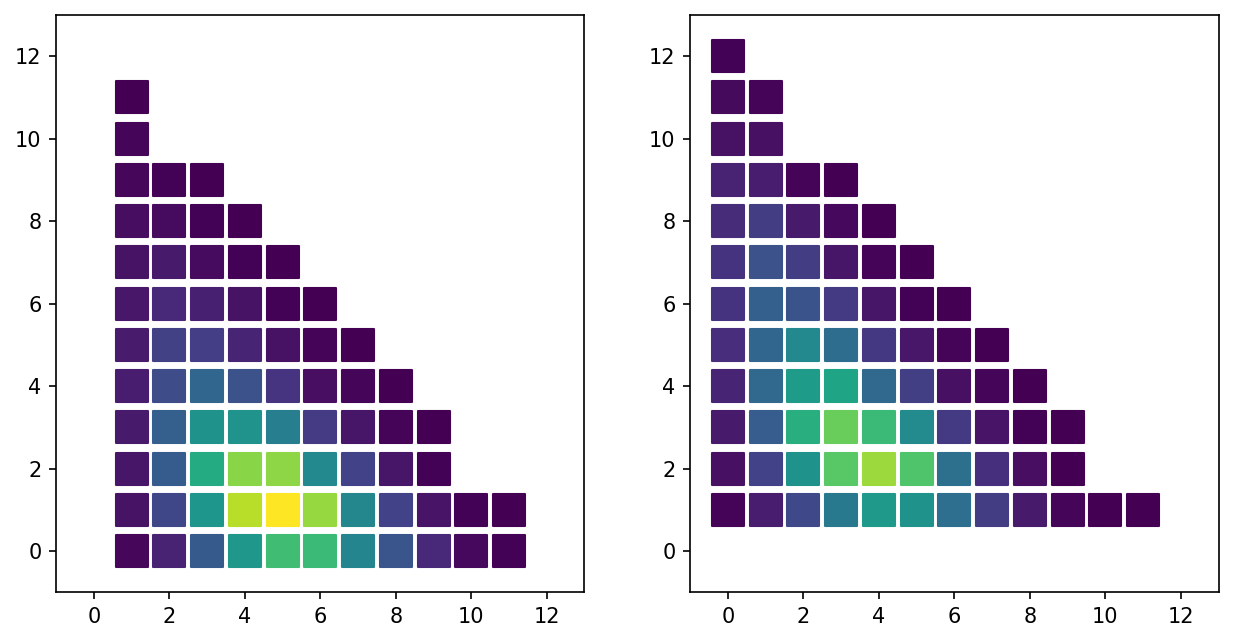

In [20]:
fig,ax=plt.subplots(1,2,figsize=(10,5),dpi=150)

for axi,fliptimepoint in enumerate(['before','after']):
    
    for y,x in flip2synbin2numflips[fliptimepoint]:
        
        n=flip2synbin2numflips[fliptimepoint][y,x]
        
        ax[axi].scatter(x,y,c=n,vmin=zmin,vmax=zmax,marker='s',s=230)
    
    ax[axi].set_ylim(-1,13)
    ax[axi].set_xlim(-1,13)
        


Text(0.5, 0, 'Number of Inert Sequences')

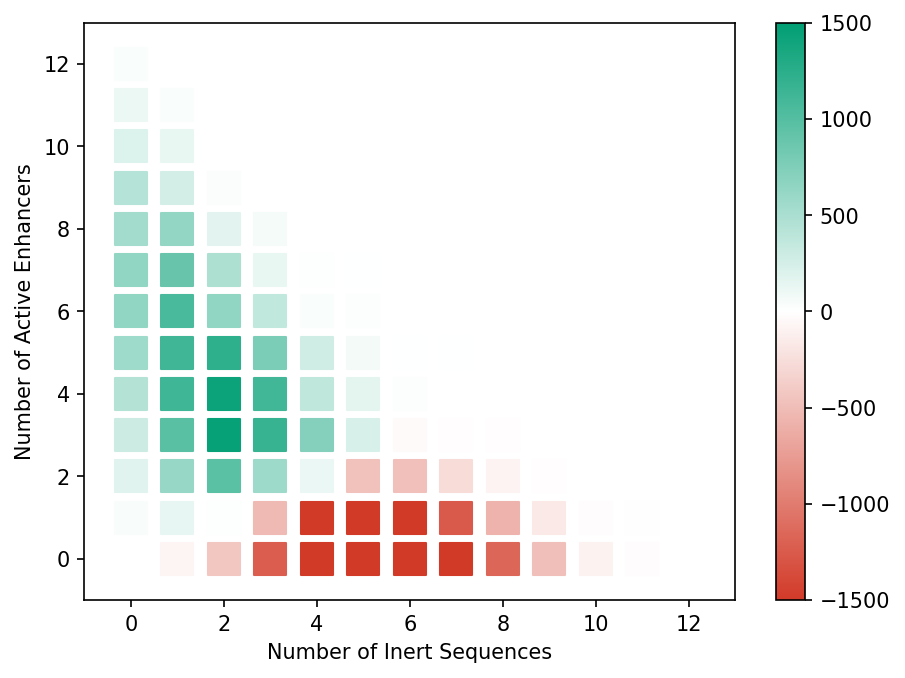

In [21]:

allDeltas=[]

cbar=True

fig,ax=plt.subplots(1,figsize=(7,5),dpi=150)

yx_spots_all=set(flip2synbin2numflips['before'].keys()) | set(flip2synbin2numflips['after'].keys())

cmap_name = 'custom_colormap'
colors = [cb['orangenature'], 'white', cb['green']]
n_bins = 1000  # Number of bins for the colormap

cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

for y,x in yx_spots_all:

    if (y,x) in flip2synbin2numflips['before']: nb=flip2synbin2numflips['before'][y,x]
    else:                                       nb=0

    if (y,x) in flip2synbin2numflips['after']:  na=flip2synbin2numflips['after'][y,x]
    else:                                       na=0

    delta=na-nb
    allDeltas.append((delta,x,y))

    mappable=ax.scatter(x,y,c=delta,vmin=-1500,vmax=1500,marker='s',s=250,cmap=cm)

if cbar:
    fig.colorbar(mappable, orientation='vertical')        

ax.set_ylim(-1,13)
ax.set_xlim(-1,13)

ax.set_ylabel('Number of Active Enhancers')
ax.set_xlabel('Number of Inert Sequences')
